In [1]:
# Comparación de métodos de escalamiento

# Objetivo: comparar Z-Score, Min-Max y Robust Scaling utilizando datos simulados de siniestros.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

siniestros = np.random.lognormal(
    mean=8,
    sigma=1,
    size=1000
)

df = pd.DataFrame({
    "monto_siniestro": siniestros
})

df.head()


,monto_siniestro
0,4898.646165
1,2596.022380
2,5696.963190
3,13670.969602
4,2358.654540


In [3]:
df.describe()

,monto_siniestro
count,1000.000000
mean,5014.967437
std,7291.874310
min,116.598063
25%,1559.953428
50%,3057.341189
75%,5698.418580
max,140467.509325


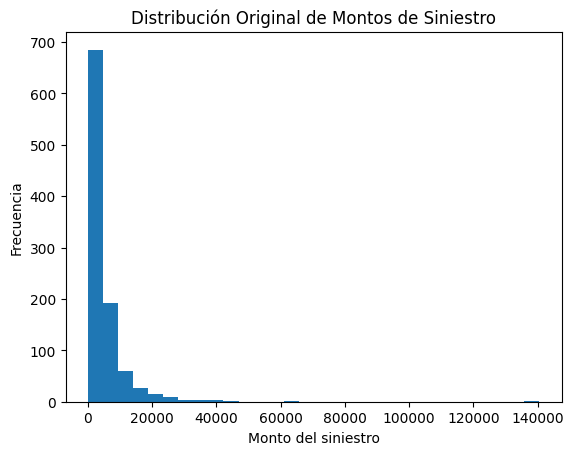

In [4]:
plt.hist(df["monto_siniestro"], bins=30)
plt.title("Distribución Original de Montos de Siniestro")
plt.xlabel("Monto del siniestro")
plt.ylabel("Frecuencia")
plt.show()

In [5]:
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler
)

df["zscore"] = StandardScaler().fit_transform(
    df[["monto_siniestro"]]
)

df["minmax"] = MinMaxScaler().fit_transform(
    df[["monto_siniestro"]]
)

df["robust"] = RobustScaler().fit_transform(
    df[["monto_siniestro"]]
)

df[["zscore", "minmax", "robust"]].describe()

,zscore,minmax,robust
count,1.000000e+03,1000.000000,1.000000e+03
mean,1.953993e-17,0.034901,4.730320e-01
std,1.000500e+00,0.051955,1.761976e+00
min,-6.720934e-01,0.000000,-7.105879e-01
25%,-4.740541e-01,0.010284,-3.618220e-01
50%,-2.686011e-01,0.020953,5.496905e-17
75%,9.377467e-02,0.039770,6.381780e-01
max,1.858511e+01,1.000000,3.320317e+01


In [6]:
comparacion = pd.DataFrame({
    "Media": [
        df["monto_siniestro"].mean(),
        df["zscore"].mean(),
        df["minmax"].mean(),
        df["robust"].mean()
    ],
    "DesvStd": [
        df["monto_siniestro"].std(),
        df["zscore"].std(),
        df["minmax"].std(),
        df["robust"].std()
    ],
    "Mediana": [
        df["monto_siniestro"].median(),
        df["zscore"].median(),
        df["minmax"].median(),
        df["robust"].median()
    ]
},
index=["Original", "Z-Score", "Min-Max", "Robust"])

comparacion

,Media,DesvStd,Mediana
Original,5.014967e+03,7291.874310,3.057341e+03
Z-Score,1.953993e-17,1.000500,-2.686011e-01
Min-Max,3.490087e-02,0.051955,2.095279e-02
Robust,4.730320e-01,1.761976,5.491484e-17


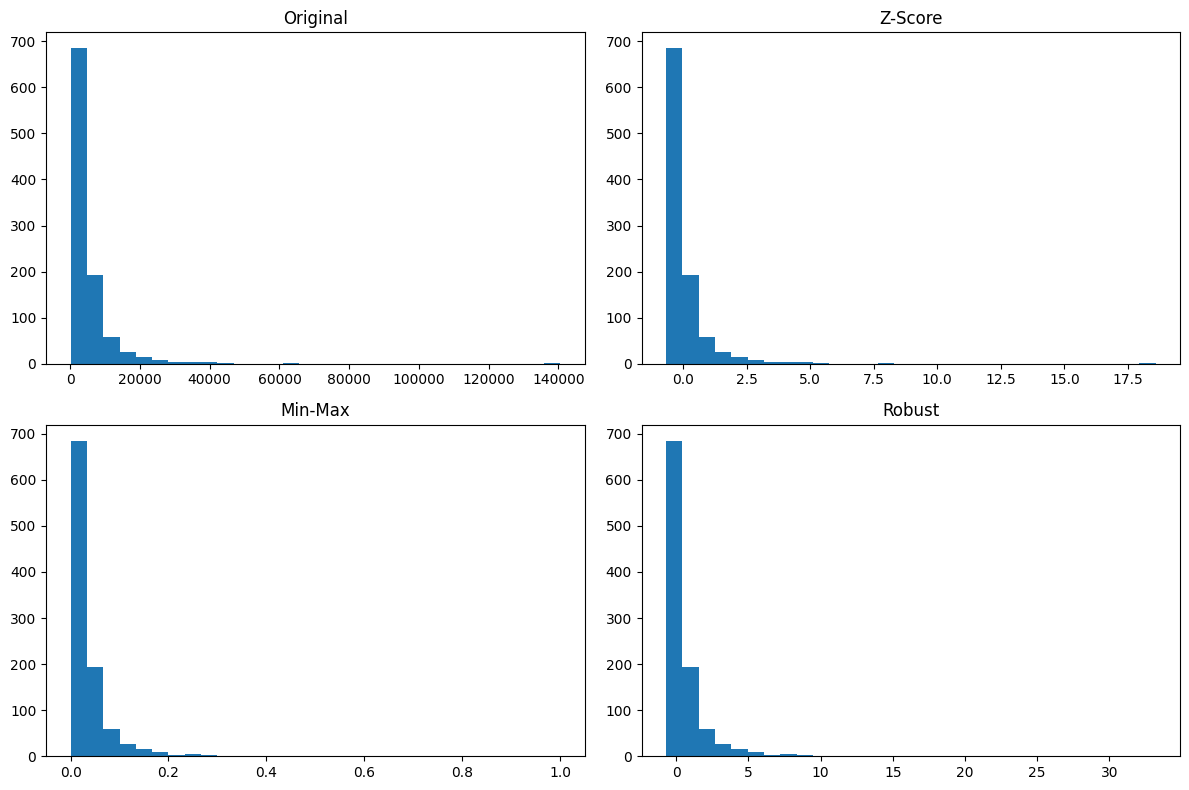

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))

axes[0,0].hist(df["monto_siniestro"], bins=30)
axes[0,0].set_title("Original")

axes[0,1].hist(df["zscore"], bins=30)
axes[0,1].set_title("Z-Score")

axes[1,0].hist(df["minmax"], bins=30)
axes[1,0].set_title("Min-Max")

axes[1,1].hist(df["robust"], bins=30)
axes[1,1].set_title("Robust")

plt.tight_layout()
plt.show()

In [8]:
# Transformaciones

# Log, Box-Cox y Yeo-Johnson


df["log"] = np.log1p(df["monto_siniestro"])

df[["monto_siniestro", "log"]].describe()


,monto_siniestro,log
count,1000.000000,1000.000000
mean,5014.967437,8.019854
std,7291.874310,0.978729
min,116.598063,4.767273
25%,1559.953428,7.353051
50%,3057.341189,8.025628
75%,5698.418580,8.648119
max,140467.509325,11.852739


In [9]:
df[["monto_siniestro", "log"]].skew()

monto_siniestro    8.311086
log                0.118401
dtype: float64

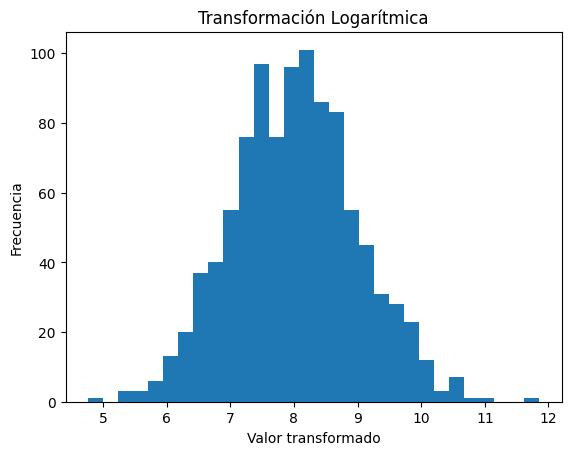

In [10]:
plt.hist(df["log"], bins=30)
plt.title("Transformación Logarítmica")
plt.xlabel("Valor transformado")
plt.ylabel("Frecuencia")
plt.show()

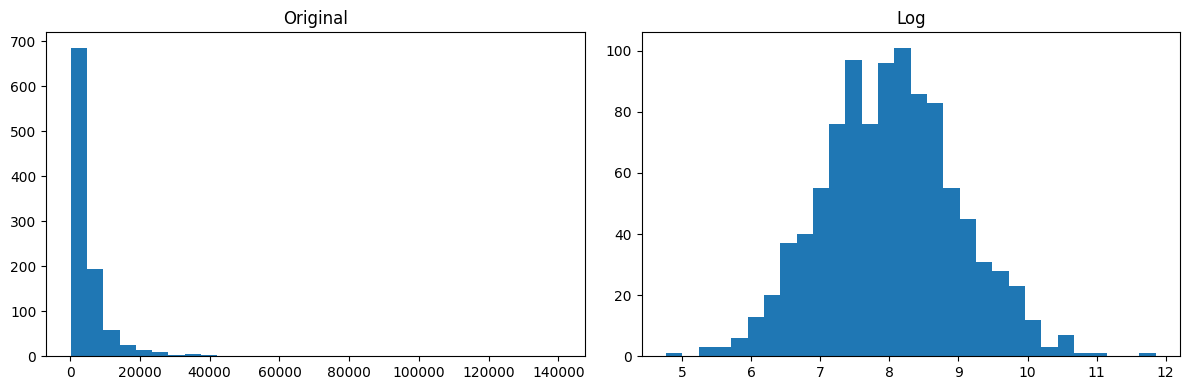

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].hist(df["monto_siniestro"], bins=30)
axes[0].set_title("Original")

axes[1].hist(df["log"], bins=30)
axes[1].set_title("Log")

plt.tight_layout()
plt.show()

In [12]:
# Box-Cox

from scipy.stats import boxcox

df["boxcox"], lambda_boxcox = boxcox(
    df["monto_siniestro"]
)

print(lambda_boxcox)
df[["boxcox"]].skew()


-0.03911422470790534


boxcox   -0.000428
dtype: float64

In [13]:
df[["monto_siniestro", "boxcox"]].describe()

,monto_siniestro,boxcox
count,1000.000000,1000.000000
mean,5014.967437,6.869750
std,7291.874310,0.714774
min,116.598063,4.342097
25%,1559.953428,6.389652
50%,3057.341189,6.887786
75%,5698.418580,7.337188
max,140467.509325,9.484821


In [14]:
df[["monto_siniestro", "boxcox"]].skew()

monto_siniestro    8.311086
boxcox            -0.000428
dtype: float64

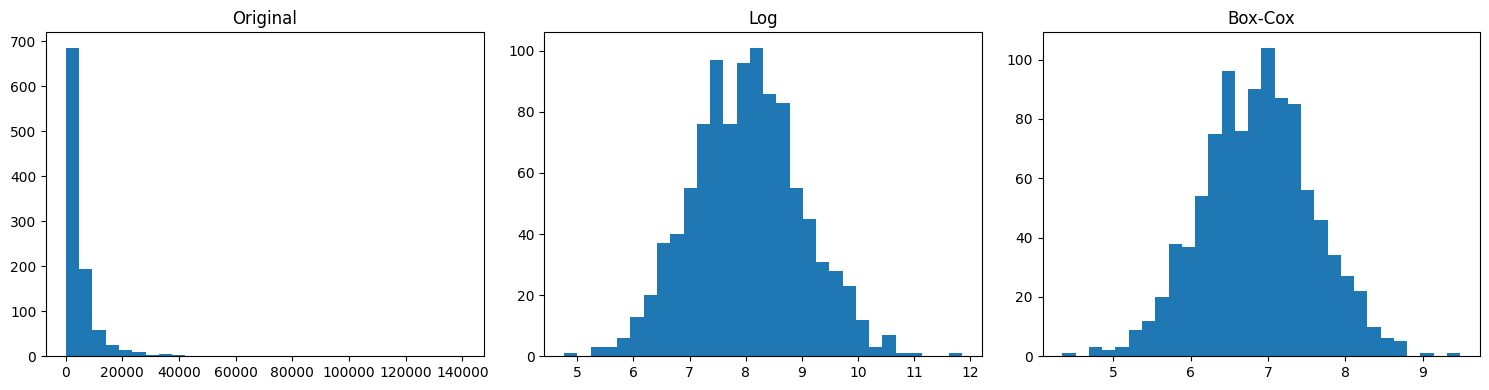

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

axes[0].hist(df["monto_siniestro"], bins=30)
axes[0].set_title("Original")

axes[1].hist(df["log"], bins=30)
axes[1].set_title("Log")

axes[2].hist(df["boxcox"], bins=30)
axes[2].set_title("Box-Cox")

plt.tight_layout()
plt.show()

In [16]:
# Yeo-Johnson

from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method="yeo-johnson")

df["yeojohnson"] = pt.fit_transform(
    df[["monto_siniestro"]]
)

df[["monto_siniestro", "yeojohnson"]].describe()

,monto_siniestro,yeojohnson
count,1000.000000,1.000000e+03
mean,5014.967437,2.566836e-16
std,7291.874310,1.000500e+00
min,116.598063,-3.533453e+00
25%,1559.953428,-6.721281e-01
50%,3057.341189,2.529478e-02
75%,5698.418580,6.544229e-01
max,140467.509325,3.658581e+00


In [17]:
df[["monto_siniestro", "yeojohnson"]].skew()

monto_siniestro    8.311086
yeojohnson        -0.000406
dtype: float64

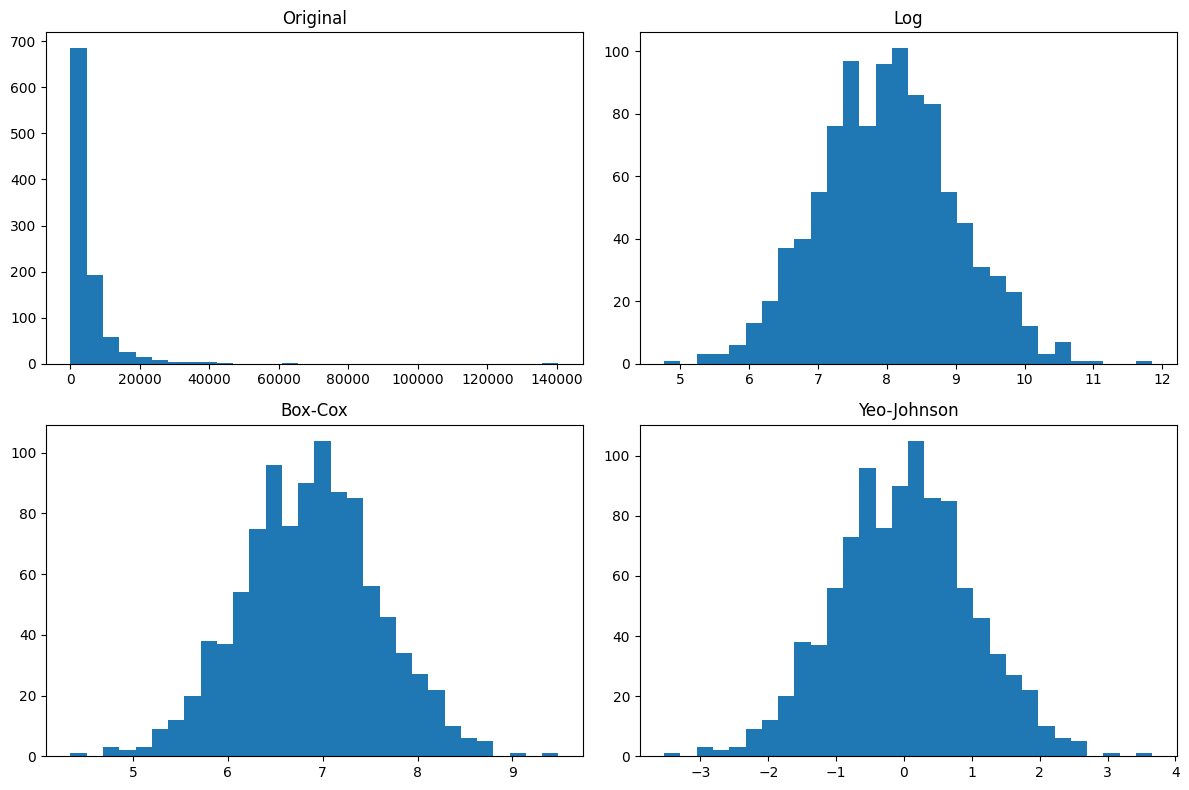

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))

axes[0,0].hist(df["monto_siniestro"], bins=30)
axes[0,0].set_title("Original")

axes[0,1].hist(df["log"], bins=30)
axes[0,1].set_title("Log")

axes[1,0].hist(df["boxcox"], bins=30)
axes[1,0].set_title("Box-Cox")

axes[1,1].hist(df["yeojohnson"], bins=30)
axes[1,1].set_title("Yeo-Johnson")

plt.tight_layout()
plt.show()

In [19]:
df[
    [
        "monto_siniestro",
        "log",
        "boxcox",
        "yeojohnson"
    ]
].skew()

monto_siniestro    8.311086
log                0.118401
boxcox            -0.000428
yeojohnson        -0.000406
dtype: float64

In [20]:
conclusion = """
Conclusión

Al aplicar los métodos de escalamiento (Z-Score, Min-Max y Robust Scaling), se observó que los datos cambiaron de escala,
pero mantuvieron prácticamente la misma forma de distribución.
Los métodos resultan útiles para estandarizar variables, pero no para corregir el sesgo de la distribución.
Después al aplicar las transformaciones distributivas Log, Box-Cox y Yeo-Johnson, obutvimos;
1. la transformación logarítmica redujo la asimetría de 8.311 a 0.118, logrando una distribución mucho más simétrica.
2. Box-Cox obtuvo -0.000428
3. Y Yeo-Johnson obtuvo los mejores resultados -0.000406 valor muy cercano a cero.

Es decir, para los datos simulados de siniestros utilizados en este ejercicio, Box-Cox y Yeo-Johnson fueron las más efectivas,
dado a que aproximaron la distribución a un comportamiento cercano a la normalidad.
"""

print(conclusion)


Conclusión

Al aplicar los métodos de escalamiento (Z-Score, Min-Max y Robust Scaling), se observó que los datos cambiaron de escala,
pero mantuvieron prácticamente la misma forma de distribución.
Los métodos resultan útiles para estandarizar variables, pero no para corregir el sesgo de la distribución.
Después al aplicar las transformaciones distributivas Log, Box-Cox y Yeo-Johnson, obutvimos;
1. la transformación logarítmica redujo la asimetría de 8.311 a 0.118, logrando una distribución mucho más simétrica.
2. Box-Cox obtuvo -0.000428
3. Y Yeo-Johnson obtuvo los mejores resultados -0.000406 valor muy cercano a cero.

Es decir, para los datos simulados de siniestros utilizados en este ejercicio, Box-Cox y Yeo-Johnson fueron las más efectivas,
dado a que aproximaron la distribución a un comportamiento cercano a la normalidad.

